## Kernel matrix compression

A kernel matrix $\mathbf K = [\kappa(x_i, x_j)]_{i,j=1}^N$ is **dense**: $N^2$ entries, $O(N^2)$
memory, $O(N^3)$ for a factorisation. That is what stops kernel methods, Gaussian processes and
boundary element solvers at a few $10^4$ points.

Samplets change the picture. Because they have vanishing moments, the matrix
$$\mathbf K_\Sigma = \mathbf T\,\mathbf K\,\mathbf T^\top$$
of the *same operator in the samplet basis* is **quasi-sparse**: all but $O(N\log N)$ entries are
below any prescribed threshold, and can be dropped.

Better still, FMCA never forms $\mathbf K$: `SampletKernelCompressor` computes the compressed
matrix directly from the a-priori sparsity pattern.

In [1]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## The dense matrix

In [2]:
N, dim, dtilde = 10000, 2, 3
pts = np.random.rand(dim, N)

ST = FMCA.SampletTree(pts, dtilde)
spts = ST.toClusterOrder(pts.T).T   # points in cluster order
ker = FMCA.CovarianceKernel("MATERN32", 0.5)

t0 = time.time()
K = ker.eval(spts, spts)
print(f"dense {N} x {N} kernel matrix: {time.time() - t0:.2f} s, {K.nbytes / 1e6:.0f} MB")
print(f"entries larger than 1e-4 (in units of |K|_max): "
      f"{100 * (np.abs(K) > 1e-4 * np.abs(K).max()).mean():.1f} %")

dense 10000 x 10000 kernel matrix: 5.02 s, 800 MB
entries larger than 1e-4 (in units of |K|_max): 100.0 %


## The same matrix in the samplet basis

T K T^T: 1.49 s


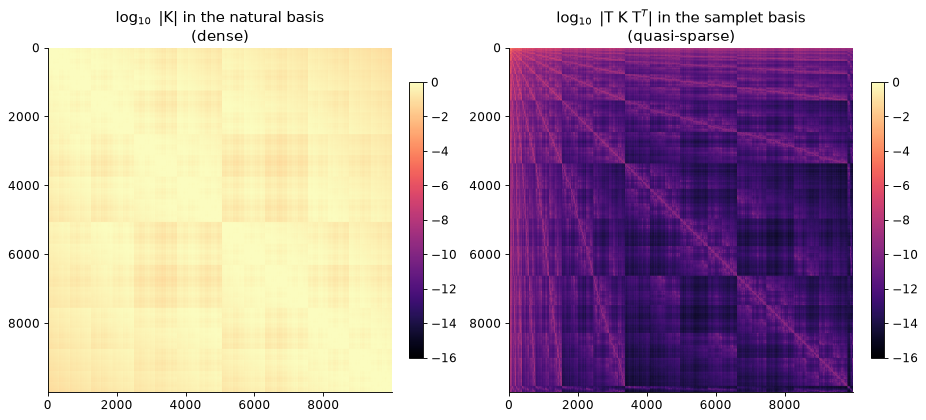

In [3]:
t0 = time.time()
KS = ST.sampletTransformMatrix(K)
print(f"T K T^T: {time.time() - t0:.2f} s")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 5))
im0 = ax[0].imshow(np.log10(np.abs(K) / np.abs(K).max() + 1e-16),
                   cmap="magma", vmin=-16, vmax=0)
ax[0].set_title("$\\log_{10}$ |K| in the natural basis\n(dense)")
im1 = ax[1].imshow(np.log10(np.abs(KS) / np.abs(KS).max() + 1e-16),
                   cmap="magma", vmin=-16, vmax=0)
ax[1].set_title("$\\log_{10}$ |T K T$^T$| in the samplet basis\n(quasi-sparse)")
for a, im in zip(ax, (im0, im1)):
    a.grid(False)
    plt.colorbar(im, ax=a, shrink=0.8)
plt.show()

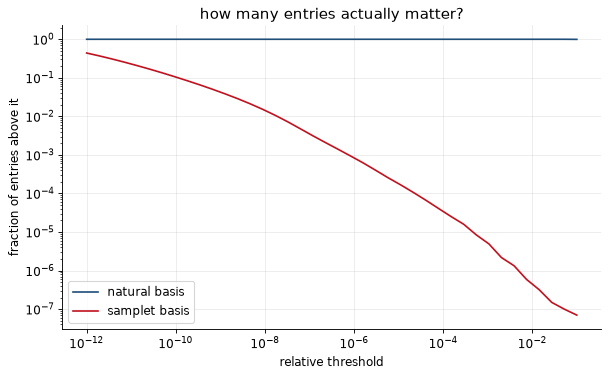

threshold 7.9e-05:  natural 100.00 %   samplet   0.00 %
threshold 8.4e-07:  natural 100.00 %   samplet   0.09 %
threshold 8.9e-09:  natural 100.00 %   samplet   1.53 %


In [4]:
levels = np.logspace(-12, -1, 40)
frac_K = [(np.abs(K) > t * np.abs(K).max()).mean() for t in levels]
frac_S = [(np.abs(KS) > t * np.abs(KS).max()).mean() for t in levels]

plt.figure(figsize=(7.5, 4.6))
plt.loglog(levels, frac_K, color=C_DATA, label="natural basis")
plt.loglog(levels, frac_S, color=C_SAMP, label="samplet basis")
plt.xlabel("relative threshold")
plt.ylabel("fraction of entries above it")
plt.title("how many entries actually matter?")
plt.legend()
plt.show()

for t in (1e-4, 1e-6, 1e-8):
    i = int(np.argmin(np.abs(levels - t)))
    print(f"threshold {levels[i]:.1e}:  natural {100*frac_K[i]:6.2f} %   "
          f"samplet {100*frac_S[i]:6.2f} %")

## The compressor

`FMCA.SampletKernelCompressor(ST, kernel, pts, eta, thres)` builds the compressed matrix
**without ever assembling $\mathbf K$**:

* `eta` &mdash; admissibility parameter of the cluster pairs (smaller = more blocks kept = more accurate),
* `thres` &mdash; a-posteriori threshold applied to the computed entries.

Only the upper triangle is stored, since the matrix is symmetric.

mpole deg:                    4
dtilde:                       3
eta:                          0.5
thres:                        1e-06
anz:                          335
compression error:            9.94071e-06
compression time            1.13 s
stored entries              3348524  (334.9 per row)
estimated relative error    9.94e-06
exact error vs. T K T^T     1.33e-05
memory                      800.0 MB dense  ->  40.22 MB sparse  (20x less)


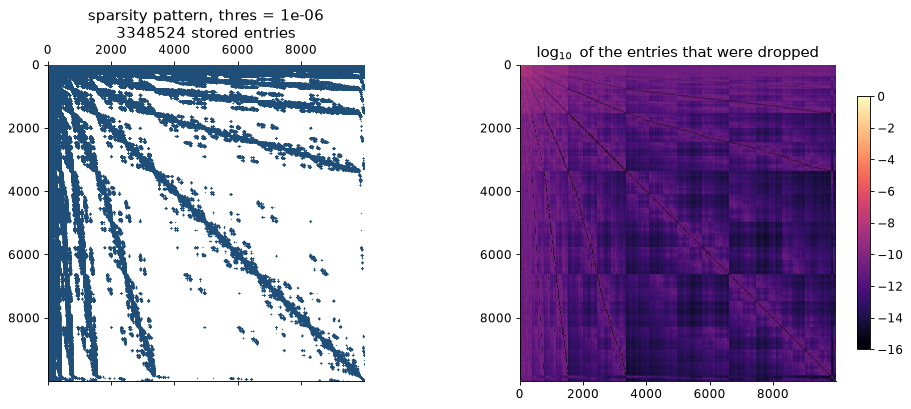

In [5]:
import scipy.sparse as sp

eta, thres = 0.5, 1e-6
t0 = time.time()
comp = FMCA.SampletKernelCompressor(ST, ker, pts, eta, thres)
t_comp = time.time() - t0

S = comp.matrix()                       # upper triangle
Sfull = S + S.T - sp.diags(S.diagonal())

mem_dense = K.nbytes / 1e6
mem_sparse = (S.data.nbytes + S.indices.nbytes + S.indptr.nbytes) / 1e6
print(f"compression time            {t_comp:.2f} s")
print(f"stored entries              {comp.nnz()}  ({comp.anz():.1f} per row)")
print(f"estimated relative error    {comp.error():.2e}")
print(f"exact error vs. T K T^T     "
      f"{np.linalg.norm(Sfull.toarray() - KS) / np.linalg.norm(KS):.2e}")
print(f"memory                      {mem_dense:.1f} MB dense  ->  {mem_sparse:.2f} MB sparse"
      f"  ({mem_dense / mem_sparse:.0f}x less)")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 5))
ax[0].spy(Sfull, markersize=0.12, color=C_DATA)
ax[0].set_title(f"sparsity pattern, thres = {thres:g}\n{comp.nnz()} stored entries")
im = ax[1].imshow(np.log10(np.abs(Sfull.toarray() - KS) / np.abs(KS).max() + 1e-18),
                  cmap="magma", vmin=-16, vmax=0)
ax[1].set_title("$\\log_{10}$ of the entries that were dropped")
for a in ax:
    a.grid(False)
plt.colorbar(im, ax=ax[1], shrink=0.8)
plt.show()

## Scaling in $N$

At a fixed threshold the number of stored entries **per row** *decreases* with $N$, so the total
memory grows essentially like $O(N\log N)$ instead of $O(N^2)$ &mdash; and the compression time
follows.

In [6]:
Ns = [2000, 4000, 8000, 16000, 32000, 64000, 128000]
anz_N, tim_N, err_N = [], [], []
for n in Ns:
    Pn = np.random.rand(2, n)
    tree = FMCA.SampletTree(Pn, 3)
    t0 = time.time()
    cmp_ = FMCA.SampletKernelCompressor(tree, ker, Pn, 0.5, 1e-6)
    tim_N.append(time.time() - t0)
    anz_N.append(cmp_.anz())
    err_N.append(cmp_.error())
    print(f"N = {n:6d}:  anz {cmp_.anz():6.0f}    "
          f"{tim_N[-1]:6.2f} s   error {cmp_.error():.1e}   "
          f"(dense would need {8 * n * n / 1e6:,.0f} MB, samplets representation needs {cmp_.nnz() * 8 / 1e6:,.2f} MB)")


N =   2000:  anz    310      0.13 s   error 1.1e-05   (dense would need 32 MB, samplets representation needs 4.96 MB)mpole deg:                    4
dtilde:                       3
eta:                          
0.5
thres:                        1e-06
anz:                          310
compression error:            1.08716e-05
mpole deg:                    4
dtilde:                       3
eta:                          N =   4000:  anz    336      0.33 s   error 1.0e-05   (dense would need 128 MB, samplets representation needs 10.74 MB)
0.5
thres:                        1e-06
anz:                          336
compression error:            1.01147e-05
mpole deg:                    4
dtilde:                       3
eta:                          N =   8000:  anz    336      0.77 s   error 1.3e-05   (dense would need 512 MB, samplets representation needs 21.52 MB)
0.5
thres:                        1e-06
anz:                          336
compression error:            1.33758e-05
mpole deg:  

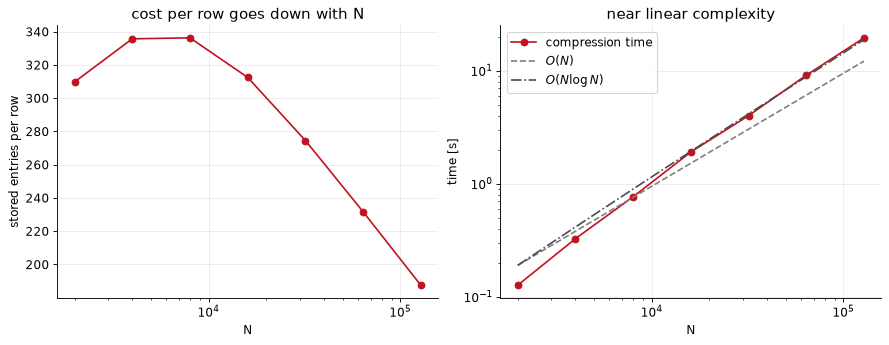

In [7]:
# O(N log N) scalato per passare vicino al primo punto
lin = np.array(Ns) / Ns[0] * tim_N[0]
lin_shifted = 1.5 * lin  
Ns_arr = np.array(Ns)
nlN = Ns_arr * np.log2(Ns_arr)
scale = tim_N[0] / nlN[0]
nlN_scaled = 1.5 * scale * nlN 

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].semilogx(Ns, anz_N, "o-", color=C_SAMP)
ax[0].set_xlabel("N"); ax[0].set_ylabel("stored entries per row")
ax[0].set_title("cost per row goes down with N")

ax[1].loglog(Ns, tim_N, "o-", color=C_SAMP, label="compression time")
ax[1].loglog(Ns, lin_shifted, "--", color="0.5", label="$O(N)$")
ax[1].loglog(Ns, nlN_scaled, "-.", color="0.3", label="$O(N\\log N)$")
ax[1].set_xlabel("N"); ax[1].set_ylabel("time [s]")
ax[1].set_title("near linear complexity")
ax[1].legend()
plt.show()

## Fast matrix-vector products

In [8]:
v = np.random.randn(N)
t0 = time.time()
for _ in range(20):
    y_dense = KS @ v
t_dense = (time.time() - t0) / 20
t0 = time.time()
for _ in range(20):
    y_sparse = Sfull @ v
t_sparse = (time.time() - t0) / 20

print(f"dense  matvec  {1e3 * t_dense:7.2f} ms")
print(f"sparse matvec  {1e3 * t_sparse:7.2f} ms   ({t_dense / t_sparse:.1f}x faster)")
print(f"relative difference {np.linalg.norm(y_dense - y_sparse) / np.linalg.norm(y_dense):.2e}")

dense  matvec    48.29 ms
sparse matvec     3.99 ms   (12.1x faster)
relative difference 3.26e-05
